# A minimal $S_4$-only axion insulator: tight-binding model and numerical checks

This notebook collects all numerics for the tight-binding model used to verify $2P_3 = z_2 \pmod 2$.
The model and shared numerical routines live in `s4_model.py`; the symmetry audit below is kept explicitly in this notebook.

## Why a new model

The model of the original Sec. III, $H=\epsilon\tau_x+\sum_i\sin k_i\,\tau_y\sigma_i+m_z\sigma_z+\delta\sin k_z\,\tau_y$,
is **inversion symmetric** with $P=\tau_x\otimes\sigma_0$ (every term is $P$-even), and therefore also $C_4$-symmetric
($C_4 = P\,S_4^{-1}$). Its $\theta=\pi$ is protected by inversion, so it cannot demonstrate an $S_4$-protected axion phase.

## The model

Basis $(c_{A\uparrow},c_{A\downarrow},c_{B\uparrow},c_{B\downarrow})$, $\tau$ = orbital, $\sigma$ = spin:
$$
H(\bm k)=\epsilon(\bm k)\,\tau_x\sigma_0+\sum_{i=x,y,z}\sin k_i\,\tau_y\sigma_i+g(\bm k)\,\tau_z\sigma_0+m_z\,\tau_0\sigma_z ,
$$
$$
\epsilon(\bm k)=\epsilon_0-\cos k_x-\cos k_y+2\cos k_z,\qquad
g(\bm k)=\eta\,(\cos k_x-\cos k_y)+\kappa\,\sin k_z ,
$$
$$
U_{S_4}=\tau_x\otimes e^{-i\frac{\pi}{4}\sigma_z},\qquad S_4\bm k=(k_y,-k_x,-k_z),\qquad U_{S_4}^4=-1 .
$$

* $\tau_z$ is odd under $U_{S_4}$, so the $S_4$-**odd** form factor $g$ makes $g\tau_z$ symmetric. It is the "fifth Dirac mass":
  it anticommutes with the whole Dirac part.
* $m_z\sigma_z$ breaks the time-reversal-like symmetry $(\tau_x\sigma_y)\mathcal K$;
  $\eta(\cos k_x-\cos k_y)\tau_z$ breaks $P$, $C_4$, $C_{2x}T$;  $\kappa\sin k_z\,\tau_z$ breaks the remaining $M_xT$, $C_{2(110)}T$.
  Character counting on $(4/mm'm')/\bar4\cong\mathbb Z_2\times\mathbb Z_2$ shows two such terms are necessary and these two are of lowest order.
* Closed-form spectrum (the $\tau_z$ mass anticommutes with the Dirac part, and $m_z\sigma_z$ commutes with $\tau_x,\tau_y\sigma_z,\tau_z$):
$$
E(\bm k)=\pm\sqrt{\big(\rho(\bm k)\pm m_z\big)^2+\sin^2k_x+\sin^2k_y},\qquad
\rho=\sqrt{\epsilon^2+\sin^2k_z+g^2}.
$$

Parameters used below: $\epsilon_0=2.4,\ m_z=0.3,\ \eta=\kappa=0.5$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import s4_model as S

S.set_style()

np.set_printoptions(precision=4, suppress=True)
P = dict(S.DEFAULT)
print("parameters:", P)

rng = np.random.default_rng(1)
K = rng.uniform(-np.pi, np.pi, (500, 3))
print("max |E_closed-form - E_eigh| =", np.abs(S.closed_form_bands(K, P) - np.linalg.eigvalsh(S.hamiltonian(K, P))).max())

parameters: {'eps0': 2.4, 'u': 1.0, 'v': 1.0, 'm_z': 0.3, 'eta': 0.5, 'kappa': 0.5, 'zeta': 0.0}
max |E_closed-form - E_eigh| = 7.993605777301127e-15


## 1. Symmetry audit: which crystalline symmetries does the model have?

The full holohedry of the stated Bravais lattice is $O_h$, whose 48 elements are the signed permutation
matrices. Taking each of them both unitary and antiunitary gives $48\times2=96$ magnetic point-operation
candidates. In both cases $R$ is the **complete** action on momentum, so an antiunitary hit at $R$ is the
operation $(-R)\,T$; since $O_h$ contains $-1$, letting $R$ run over all of $O_h$ in both lines exhausts
$O_h+O_hT$. For each candidate we do **not** guess a representation matrix but solve the linear system
$$
H(Rk)\,U-U\,H(k)=0\ \ (\text{unitary}),\\ H(Rk)\,U-U\,H(k)^*=0\ \ (\text{antiunitary})
$$
for a constant $4\times4$ matrix $U$ over 40 random momenta (640 equations for 16 unknowns), and accept a
candidate only when its null space is **one-dimensional** and its normalized generator is **unitary**;
anything else is printed and rejected. Both orbitals sit at the same Wyckoff position, so the
point-operation part of $U$ is momentum independent: any Bloch phase (from a fractional translation, or from
an operation centred away from the origin) is a scalar here and cancels from a relation that is linear in $U$
on both sides. The same 96-candidate scan is used for the reduced models further down, so the enlarged groups
are determined over the full cubic holohedry as well.


In [2]:
EXPECTED_BAR4 = {"E", "C2z", "S4z+", "S4z-"}

def same_up_to_phase(A, B):
    """True if the two 4x4 unitaries differ only by an overall phase."""
    return abs(abs(np.trace(A.conj().T @ B)) / 4 - 1) < 1e-10

print("Full O_h x {1,T} audit (48 unitary + 48 antiunitary candidates):")
labels, found = S.magnetic_point_group(lambda k: S.hamiltonian(k, P), verbose=True, return_details=True)
assert len(found) == 4
assert set(labels) == EXPECTED_BAR4
assert all(d["nullity"] == 1 and d["unitarity_error"] < 1e-10 for d in found)
assert not any(d["antiunitary"] for d in found)
print("  -> exactly bar(4) = {E, C2z, S4z+, S4z-}; no antiunitary symmetry")

# the representation matrices come out of the null space; nothing was assumed except U_S4 itself
U_found = {d["label"]: d["U"] for d in found}
print("  U(E)    = 1                :", same_up_to_phase(U_found["E"], np.eye(4)))
print("  U(C2z)  = U_S4^2 = -i s_z  :", same_up_to_phase(U_found["C2z"], S.U_C2))
print("  U(S4z+) = U_S4             :", same_up_to_phase(U_found["S4z+"], S.U_S4))
print("  U(S4z-) = U_S4^{-1}        :", same_up_to_phase(U_found["S4z-"], S.U_S4.conj().T))
print("  U_S4^4 = -1 (double group) :", np.abs(np.linalg.matrix_power(S.U_S4, 4) + np.eye(4)).max() < 1e-12)

print("\nSame 96-candidate audit with one perturbation removed at a time:")
reduced = [("without eta  ", lambda k: S.hamiltonian(k, dict(P, eta=0))),
           ("without kappa", lambda k: S.hamiltonian(k, dict(P, kappa=0))),
           ("without m_z  ", lambda k: S.hamiltonian(k, dict(P, m_z=0))),
           ("old Eq.(12)  ", S.hamiltonian_old)]
for name, hfun in reduced:
    print(f"  {name}: {sorted(S.magnetic_point_group(hfun))}")


Full O_h x {1,T} audit (48 unitary + 48 antiunitary candidates):
    C2z          unitary     nullity=1 unitarity err=1.3e-15
    E            unitary     nullity=1 unitarity err=1.3e-15
    S4z-         unitary     nullity=1 unitarity err=1.3e-15
    S4z+         unitary     nullity=1 unitarity err=1.3e-15
  -> exactly bar(4) = {E, C2z, S4z+, S4z-}; no antiunitary symmetry
  U(E)    = 1                : True
  U(C2z)  = U_S4^2 = -i s_z  : True
  U(S4z+) = U_S4             : True
  U(S4z-) = U_S4^{-1}        : True
  U_S4^4 = -1 (double group) : True

Same 96-candidate audit with one perturbation removed at a time:
  without eta  : ['C2(1-10)T', 'C2(110)T', 'C2xT', 'C2yT', 'C2z', 'C4z+', 'C4z-', 'E', 'M(1-10)T', 'M(110)T', 'MxT', 'MyT', 'Mz', 'P', 'S4z+', 'S4z-']
  without kappa: ['C2(1-10)T', 'C2(110)T', 'C2z', 'E', 'MxT', 'MyT', 'S4z+', 'S4z-']
  without m_z  : ['C2z', 'C4z+T', 'C4z-T', 'E', 'MzT', 'PT', 'S4z+', 'S4z-']
  old Eq.(12)  : ['C2(1-10)T', 'C2(110)T', 'C2xT', 'C2yT', 'C2z'

The full 96-operation audit finds exactly the magnetic point group $\bar 4=\{E,S_4^\pm,C_{2z}\}$. Its only
orientation-reversing elements, and hence its only unitary symmetries that quantize $\theta$, are $S_4^\pm$.
The proper rotation $C_4$ does not quantize $\theta$ by itself; if it were present alongside $S_4$, however, their
product would generate inversion. Removing any one term restores a larger group, and the old model has $4/mm'm'$
including both $P$ and $C_4$.

## 2. Band structure and density of states
Two bands (blue) are occupied. Path: $\Gamma$–X–M–A–Z–$\Gamma$–R–A.
Energies are in units of the hopping $u$ ($u=v=1$). The DOS is Gaussian-broadened ($\sigma=0.05u$, $64^3$ grid) and normalised to 4 states per unit cell. Figures are saved as PNG and PDF in `figure/`.

minimal bulk gap E3-E2 = 1.4415 at k/pi = [ 0.     -1.     -0.9264]


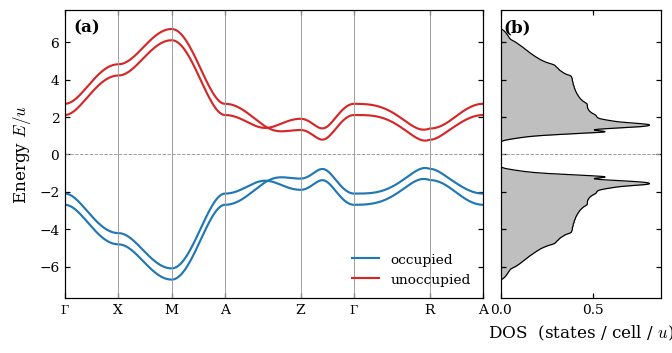

In [3]:
fig = S.plot_bands_dos(P)
S.save_figure(fig, "figure/S4model_bands_dos")
gap, kgap = S.min_gap(P)
print(f"minimal bulk gap E3-E2 = {gap:.4f} at k/pi = {kgap/np.pi}")

## 3. Symmetry eigenvalues, symmetry indicators, Chern numbers

Conventions (MSG 81.33, $P\bar4$): $n_K^{\pm1/2}$, $n_K^{\pm3/2}$ count occupied states with $S_4$ eigenvalue
$e^{\mp i\pi/4}$, $e^{\mp i3\pi/4}$ at $K\in\{\Gamma,Z,M,A\}$; $n_R^{\pm1/2}$ counts $(S_4)^2$ eigenvalues $e^{\mp i\pi/2}$ at $R$.
$$
z_{4S}=-\tfrac12 n_Z^{1/2}+\tfrac12 n_Z^{-1/2}-\tfrac32 n_Z^{3/2}+\tfrac32 n_Z^{-3/2}
-\tfrac12 n_A^{1/2}+\tfrac12 n_A^{-1/2}-\tfrac32 n_A^{3/2}+\tfrac32 n_A^{-3/2}+n_R^{1/2}-n_R^{-1/2}\ \ (\mathrm{mod}\ 4)
$$
$$
\delta_{2S}=-n_Z^{3/2}+n_Z^{-3/2}-n_A^{3/2}+n_A^{-3/2}+n_\Gamma^{3/2}-n_\Gamma^{-3/2}+n_M^{3/2}-n_M^{-3/2}\ \ (\mathrm{mod}\ 2),\qquad
z_2=\sum_{K\in K^4}\frac{n_K^{1/2}-n_K^{-3/2}}{2}\ \ (\mathrm{mod}\ 2).
$$
$(z_{4S},\delta_{2S},z_2)=(0,0,1)$ with vanishing Chern numbers is the axion insulator.

In [4]:
(z4, d2, z2), n, nR = S.indicators(P)
for Kname in n:
    print(f"  {Kname}: S4 labels of occupied bands = {[lab for lab, c in n[Kname].items() if c]}")
print(f"  R : C2 labels = {[lab for lab, c in nR.items() if c]}")
print(f"\n(z4S, d2S, z2) = ({z4}, {d2}, {z2})")
print("Chern numbers of the occupied space:", S.all_chern(P))
for Kname, k in S.K4.items():
    w = np.linalg.eigvalsh(S.hamiltonian(np.array(k, float), P))
    print(f"  occupied energies at {Kname}: {w[:2]}  (splitting {w[1]-w[0]:.3f} = 2 m_z)")

  G: S4 labels of occupied bands = ['3/2', '-3/2']
  Z: S4 labels of occupied bands = ['1/2', '-1/2']
  M: S4 labels of occupied bands = ['3/2', '-3/2']
  A: S4 labels of occupied bands = ['3/2', '-3/2']
  R : C2 labels = ['1/2', '-1/2']

(z4S, d2S, z2) = (0, 0, 1)
Chern numbers of the occupied space: {'C_x(0)': 0, 'C_x(pi)': 0, 'C_y(0)': 0, 'C_y(pi)': 0, 'C_z(0)': 0, 'C_z(pi)': 0}
  occupied energies at G: [-2.7 -2.1]  (splitting 0.600 = 2 m_z)
  occupied energies at Z: [-1.9 -1.3]  (splitting 0.600 = 2 m_z)
  occupied energies at M: [-6.7 -6.1]  (splitting 0.600 = 2 m_z)
  occupied energies at A: [-2.7 -2.1]  (splitting 0.600 = 2 m_z)


## 4. Degeneracies inside the occupied space are symmetry-enforced

The two occupied bands are non-degenerate almost everywhere (split by $2m_z$ at all $K^4$ points), but they touch at
four Weyl points. From the closed form, $E_2=E_1$ requires $\rho=0$, i.e.
$$
\sin k_z=0,\qquad g=\eta(\cos k_x-\cos k_y)=0\ \Rightarrow\ k_x=\pm k_y,\qquad \epsilon(\bm k)=0 ,
$$
which on $k_z=\pi$ gives $\cos k^*=(\epsilon_0-2)/2$ (solvable iff $0\le\epsilon_0\le4$; on $k_z=0$ iff $-4\le\epsilon_0\le0$).
The four nodes $(\pm k^*,\mp k^*,\pi),(\pm k^*,\pm k^*,\pi)$ form one $S_4$ orbit with alternating chirality.

They cannot be removed: the Chern number of the **lowest band alone** differs by 2 between the planes $k_z=0$ and
$k_z=\pi$ (fixed mod 4 by the $S_4$ eigenvalues on the two $S_4$-invariant planes), whereas an isolated band would have the
same Chern number on every $k_z$ plane. This is the $S_4$ analogue of Kramers pairing and is why the proof works with
$2\times2$ blocks. It does **not** affect $2P_3$, which only needs the occupied/unoccupied gap.

In [5]:
kstar = np.arccos((P["eps0"] - 2) / 2)
sval, kmin = S.min_occupied_splitting(P)
print(f"min occupied splitting = {sval:.2e} at k/pi = {kmin/np.pi};  predicted k*/pi = {kstar/np.pi:.4f}")
for k0 in [(kstar, -kstar, np.pi), (kstar, kstar, np.pi), (-kstar, kstar, np.pi), (-kstar, -kstar, np.pi)]:
    print(f"  node k/pi = {np.round(np.array(k0)/np.pi, 4)}: chirality of band 1 = {S.band_chirality(P, np.array(k0)):+.2f}")

# push the nodes off the kz = pi plane with an S4-symmetric zeta term, so both planes are regular
Pz = dict(P, zeta=0.4)
sz_, kz_ = S.min_occupied_splitting(Pz)
print(f"\nwith zeta=0.4 the nodes sit at kz/pi = {abs(kz_[2])/np.pi:.3f}")
for lab, ax, v in (("kz=0", 2, 0.0), ("kz=pi", 2, np.pi), ("kx=0", 0, 0.0), ("kx=pi", 0, np.pi)):
    print(f"  lowest band alone: C({lab}) = {S.chern_plane(Pz, ax, v, bands=(0,))}")
print("no nodes in the trivial phase:  min occupied splitting at eps0=5 :", f"{S.min_occupied_splitting(dict(P, eps0=5.0))[0]:.3f}")

min occupied splitting = 1.56e-12 at k/pi = [-0.4359  0.4359 -1.    ];  predicted k*/pi = 0.4359
  node k/pi = [ 0.4359 -0.4359  1.    ]: chirality of band 1 = -1.00
  node k/pi = [0.4359 0.4359 1.    ]: chirality of band 1 = +1.00
  node k/pi = [-0.4359  0.4359  1.    ]: chirality of band 1 = -1.00
  node k/pi = [-0.4359 -0.4359  1.    ]: chirality of band 1 = +1.00

with zeta=0.4 the nodes sit at kz/pi = 0.733
  lowest band alone: C(kz=0) = 0
  lowest band alone: C(kz=pi) = 2
  lowest band alone: C(kx=0) = 0
  lowest band alone: C(kx=pi) = 0
no nodes in the trivial phase:  min occupied splitting at eps0=5 : 0.505


## 5. $2P_3$ from the $S_4$ sewing matrix

$$
2P_3=-\frac{1}{24\pi^2}\int d^3k\,\epsilon^{ijk}\,\mathrm{Tr}\!\left[(B^\dagger\partial_iB)(B^\dagger\partial_jB)(B^\dagger\partial_kB)\right],
\qquad B_{mn}(\bm k)=\langle u_m(S_4\bm k)|U_{S_4}|u_n(\bm k)\rangle .
$$
$B$ is gauge-*covariant*, $B\to G^\dagger(S_4\bm k)BG(\bm k)$, and the integral is only invariant (mod 2) under **smooth periodic**
$G$. Eigenvectors from `eigh` carry a random $U(2)$ gauge at every $\bm k$, so we build a global smooth periodic frame from the
gauge-invariant projector,
$$
U_{\rm occ}(\bm k)=P_{\rm occ}(\bm k)R\,\big(R^\dagger P_{\rm occ}(\bm k)R\big)^{-1/2},\qquad P_{\rm occ}=\sum_{n\in\rm occ}|u_n\rangle\langle u_n| ,
$$
with a fixed reference $R\in\mathbb C^{4\times2}$ chosen to maximise the minimal overlap. Then $\det B$ is reduced to 1 by a
continuous half-phase (allowed because $\det B$ has no winding) and the integral is evaluated with periodic central differences.

*Remark.* Multiplying $B$ by a smooth $U(1)$ phase does not change the winding density (the abelian part drops out of $\epsilon^{ijk}\mathrm{Tr}[A_iA_jA_k]$), so the $\det B=1$ reduction is a convenience, not a requirement. The constant-reference frame used here is *not* robust across parameters; Sec. 8 replaces it.

*Note* The constant-reference projector frame (`projector_frames`, used by the old `two_p3`) is now only a historical object.

In [6]:
for nk in (32, 48, 64):
    S.two_p3(P, nk=nk)

    reference frame 'B-orb' (min overlap eigenvalue 0.032)
    nk=32: |det B|-1 max = 2.4e-15, det-B winding = 1.3e-31, 2P3 = +0.9459+7.5e-20j
    reference frame 'B-orb' (min overlap eigenvalue 0.032)
    nk=48: |det B|-1 max = 2.2e-15, det-B winding = 1.6e-31, 2P3 = +0.9749+9.4e-19j
    reference frame 'B-orb' (min overlap eigenvalue 0.032)
    nk=64: |det B|-1 max = 2.7e-15, det-B winding = 2.5e-31, 2P3 = +0.9856+1.6e-18j


### Why the "stitched" parallel-transport gauge gives $2P_3=0$

Sequential parallel transport ($x$-line, then $y$-lines, then $z$-lines) makes each new frame have positive-Hermitian overlap with
the previous one, i.e. it sets the Berry connection along the last transport direction to zero:
$\mathcal A_z=iU^\dagger\partial_zU=0$, so $\partial_zU=(1-P_{\rm occ})\partial_zU$. Because $U_{S_4}$ maps the occupied space at
$\bm k$ onto that at $S_4\bm k$, both terms of $\partial_zB$ then vanish:
$$
B^\dagger\partial_zB\equiv0\quad\Longrightarrow\quad \epsilon^{ijk}\mathrm{Tr}[A_iA_jA_k]\equiv0
$$
pointwise. The whole winding is pushed into the seam $k_z=-\pi$, where the frame jumps by the Wilson loop,
$B\to W_z(S_4\bm k)^\dagger BW_z(\bm k)$ — a delta function that finite differences cannot integrate. The cell below reproduces this.

In [7]:
val, Az_bulk, Az_seam = S.two_p3_parallel_transport(P, nk=24)
print(f"parallel-transport gauge, nk=24:  2P3 = {val:+.4f};   max|B^+ d_z B| away from seam = {Az_bulk:.1e},  at the seam = {Az_seam:.1e}")

parallel-transport gauge, nk=24:  2P3 = -0.0000;   max|B^+ d_z B| away from seam = 5.7e-15,  at the seam = 3.8e+00


## 6. Wilson loop along $k_z$ (gauge-invariant cross-check)
$W_z(k_x,k_y)=\prod_{k_z}U^\dagger(\bm k)U(\bm k+\delta k\hat z)$; the two eigenphases along $\Gamma$–X–M–Y–$\Gamma$ wind by $\pi$
(gapless spectrum pinned at $\theta=\pi$ at $\Gamma$ and $0$ at M), as expected for an axion insulator.

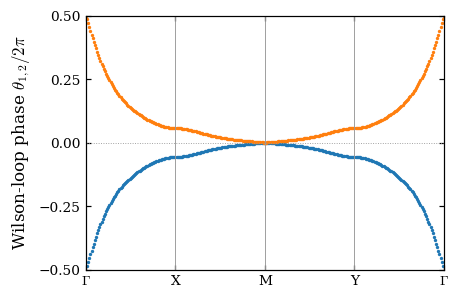

In [8]:
fig = S.plot_wilson(P)
S.save_figure(fig, "figure/S4model_wilson_z")

## 7. Phase diagram

With the closed-form spectrum the gap $E_3-E_2=2\min\sqrt{(\rho-m_z)^2+\sin^2k_x+\sin^2k_y}$ can only close on the four $C_2$ lines
$(k_x,k_y)\in\{(0,0),(\pi,\pi),(\pi,0),(0,\pi)\}$ where $\rho(k_z)=m_z$. For small $m_z$ this gives Weyl-semimetal wedges at
$\epsilon_0=4\pm m_z$ (inversion at $Z$), $\pm m_z$ ($\Gamma$ and $A$) and $-4\pm m_z$ ($M$); the inversions at $X,R$
($\epsilon_0=\pm2$) do not close the gap once $2\eta>m_z$. Between the wedges: trivial for $|\epsilon_0|>4+m_z$, $z_2=1$ axion
insulator for $m_z<|\epsilon_0|<4-m_z$. Every insulating point has $z_{4S}=\delta_{2S}=0$ (no hatching).
The star marks the parameters used above.

In [9]:
print(f"{'eps0':>6} {'gap':>7} {'(z4S,d2S,z2)':>13} {'Chern(occ)':>16} {'2P3':>8}")
for eps0 in (5.0, 3.0, 1.0, -1.0, -3.0, -5.0):
    q = dict(P, eps0=eps0)
    ind = S.indicators(q)[0]; ch = ",".join(str(v) for v in S.all_chern(q, nk=30).values())
    val, _, _ = S.two_p3(q, nk=40, verbose=False)
    print(f"{eps0:6.1f} {S.analytic_gap(q):7.3f} {str(ind):>13} {ch:>16} {val:+8.3f}")

  eps0     gap  (z4S,d2S,z2)       Chern(occ)      2P3
   5.0   1.400     (0, 0, 0)      0,0,0,0,0,0   +0.000
   3.0   1.185     (0, 0, 1)      0,0,0,0,0,0   -0.976
   1.0   1.185     (0, 0, 1)      0,0,0,0,0,0   -0.977
  -1.0   1.185     (0, 0, 1)      0,0,0,0,0,0   +0.977
  -3.0   1.185     (0, 0, 1)      0,0,0,0,0,0   +0.976
  -5.0   1.400     (0, 0, 0)      0,0,0,0,0,0   +0.000


exact phase boundaries in eps0 (m_z=0.3): [-4.301 -3.701 -0.301  0.3    3.699  4.299]


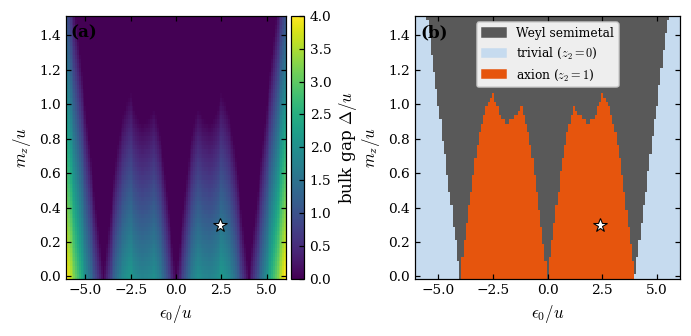

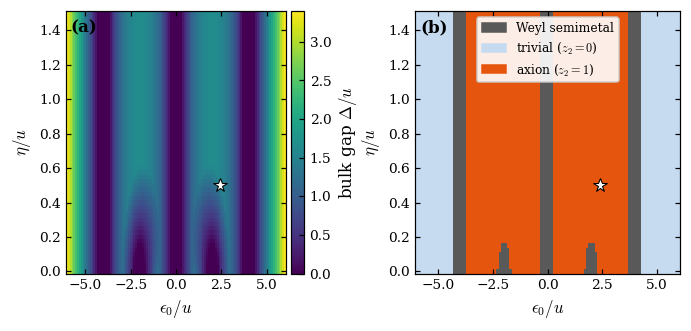

In [10]:
xs = np.linspace(-6, 6, 121)
fig, _ = S.phase_diagram("eps0", xs, "m_z", np.linspace(0.0, 1.5, 61), P, mark=(P["eps0"], P["m_z"]))
S.save_figure(fig, "figure/S4model_phase_eps0_mz")
fig, _ = S.phase_diagram("eps0", xs, "eta", np.linspace(0.0, 1.5, 61), P, mark=(P["eps0"], P["eta"]))
S.save_figure(fig, "figure/S4model_phase_eps0_eta")

e = np.linspace(-6, 6, 12001)
g = np.array([S.gapless(dict(P, eps0=v)) for v in e])
print("exact phase boundaries in eps0 (m_z=0.3):", np.round(e[np.where(np.diff(g.astype(int)) != 0)[0]], 3))

## 8. $2P_3$ across the phase diagram, compared with $z_2$

### A robust global smooth frame

The constant-reference frame $U_{\rm occ}=P_{\rm occ}R\,(R^\dagger P_{\rm occ}R)^{-1/2}$ of Sec. 5 is smooth only where
$R^\dagger P_{\rm occ}R$ is invertible. Its first column is harmless (a constant-reference section of a rank-2 bundle over
$T^3$ vanishes only on a codimension-4 set, i.e. nowhere), but its second column is effectively a constant-reference section
of the *line* bundle orthogonal to the first, and such a section generically vanishes on **curves** in the BZ. At the
reference point the orbital references happen to work (minimal overlap eigenvalue $0.03$), but scanning the parameters shows
the overlap shrinking steadily with $m_z$ ($0.035\to 0.011$ at $m_z=1$, still inside the axion phase, and $0$ in the
semimetal), so the frame becomes arbitrarily rough and `two_p3` cannot be used across the phase diagram.

`smooth_frames` builds the frame in a way that only assumes what is needed for a global frame to exist (all six plane Chern
numbers vanish):
$$
e_1(\bm k)=\frac{P_{\rm occ}(\bm k)\,r_1}{|P_{\rm occ}(\bm k)\,r_1|}\quad(r_1\ \text{generic constant}),\qquad
e_2(\bm k)\in L=\mathrm{occ}\ominus e_1 ,
$$
where $e_2$ is obtained by parallel transport of the abelian line bundle $L$ along $k_x$ (one line), $k_y$ (the plane
$k_z=-\pi$) and $k_z$ (the bulk). At every periodic seam the Berry-phase mismatch $\phi$ is a smooth function of the
transverse momenta *with zero winding* (because $c_1(L)=c_1({\rm occ})-c_1(\mathrm{span}\,e_1)=0$), so it can be unwrapped
and removed by the linear twist $e^{-i\phi\,(k+\pi)/2\pi}$. The result is smooth and periodic on the grid, and the largest
change of $U$ between neighbouring grid points is monitored (`max_step`).

### An independent check: the Chern–Simons integral itself

With a smooth periodic frame at hand, $P_3$ can be evaluated **directly**,
$$
P_3=-\frac{1}{8\pi^2}\int d^3k\,\epsilon^{ijk}\,\mathrm{Tr}\!\left[\mathcal A_i\partial_j\mathcal A_k-\tfrac{2i}{3}\mathcal A_i\mathcal A_j\mathcal A_k\right]\pmod 1,
\qquad \mathcal A_i=iU^\dagger\partial_iU ,
$$
which does not use $S_4$ at all. Agreement of this number (mod 1) with the sewing-matrix winding (mod 2) tests the identity
$2P_3=W[B]\bmod 2$ numerically rather than assuming it; agreement with $z_2$ tests the symmetry-indicator formula.


In [11]:
print("reference point, robust frame:")
for nk in (24, 32, 48):
    S.two_p3_smooth(P, nk=nk, verbose=True)
print("\ndifferent random references (nk=24) must agree mod 2:")
for seed in range(4):
    r = S.two_p3_smooth(P, nk=24, seed=seed)
    print(f"  seed {seed}:  W[B] = {r['winding']:+.3f},  2P3 (direct CS) = {r['cs']:+.3f}")
print("\nconstant-reference frame of Sec. 5 loses its overlap at large m_z (same eps0):")
for mz in (0.3, 0.6, 1.0, 1.3):
    _, m = S.projector_frames(dict(P, m_z=mz), 20, ref=S.REFS["B-orb"], verbose=False)
    print(f"  m_z = {mz}: min overlap eigenvalue = {m:.4f},  gapless = {S.gapless(dict(P, m_z=mz))}")

reference point, robust frame:
    smooth frame nk=24: min|P r1| = 0.325, seam windings (y,z) = (8.5e-03, 2.0e-02), max grid step = 0.329, orthonormality err = 1.1e-15
    nk=24: 2P3 (sewing-matrix winding) = +0.9247,  2P3 (direct Chern-Simons) = +0.9248
    smooth frame nk=32: min|P r1| = 0.320, seam windings (y,z) = (6.0e-03, 1.6e-02), max grid step = 0.257, orthonormality err = 1.2e-15
    nk=32: 2P3 (sewing-matrix winding) = +0.9567,  2P3 (direct Chern-Simons) = +0.9565
    smooth frame nk=48: min|P r1| = 0.320, seam windings (y,z) = (3.7e-03, 1.2e-02), max grid step = 0.172, orthonormality err = 1.2e-15
    nk=48: 2P3 (sewing-matrix winding) = +0.9804,  2P3 (direct Chern-Simons) = +0.9803

different random references (nk=24) must agree mod 2:
  seed 0:  W[B] = +0.925,  2P3 (direct CS) = +0.925
  seed 1:  W[B] = -0.920,  2P3 (direct CS) = -0.902
  seed 2:  W[B] = -0.903,  2P3 (direct CS) = -0.875
  seed 3:  W[B] = -0.898,  2P3 (direct CS) = -0.897

constant-reference frame of Sec. 

### The maps

For every insulating point of the two phase diagrams with vanishing plane Chern numbers we compute $z_2$, the sewing-matrix
winding $W[B]$ and the direct Chern–Simons value $2P_3$. The $k$-grid starts at $n_k=24$ and is refined
($36,48,64$) whenever the frame is not smooth on the grid (`max_step` $>0.6$), which happens only next to the phase
boundaries where the bulk gap is tiny. Both $2P_3$ panels show the value folded modulo 2 (distance from the nearest even
integer: $0$ = trivial, $1$ = axion); a point is called *resolved* when it is within $0.3$ of an integer.


eps0 x m_z map:
    eps0 = -6.00: 31 insulating points done, 6 s
    eps0 = -4.00: 208 insulating points done, 56 s
    eps0 = -2.00: 368 insulating points done, 174 s
    eps0 = +0.00: 502 insulating points done, 514 s
    eps0 = +2.00: 658 insulating points done, 788 s
    eps0 = +4.00: 798 insulating points done, 928 s
    eps0 = +6.00: 1009 insulating points done, 984 s
  winding : {'n_points': 1009, 'n_unresolved': 4, 'n_mismatch': 0, 'worst_resolved': 0.2880120355063176, 'n_nonzero_chern': 0, 'nk_used': {24: 740, 36: 130, 48: 52, 64: 87}}
  cs      : {'n_points': 1009, 'n_unresolved': 7, 'n_mismatch': 0, 'worst_resolved': 0.29691027957517546, 'n_nonzero_chern': 0, 'nk_used': {24: 740, 36: 130, 48: 52, 64: 87}}
eps0 x eta map:
    eps0 = -6.00: 31 insulating points done, 6 s
    eps0 = -4.00: 279 insulating points done, 58 s
    eps0 = -2.00: 551 insulating points done, 239 s
    eps0 = +0.00: 796 insulating points done, 489 s
    eps0 = +2.00: 1068 insulating points done, 732 s
 

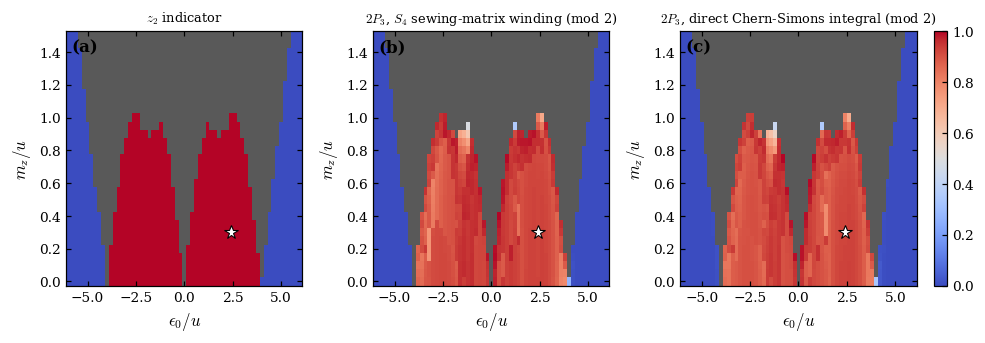

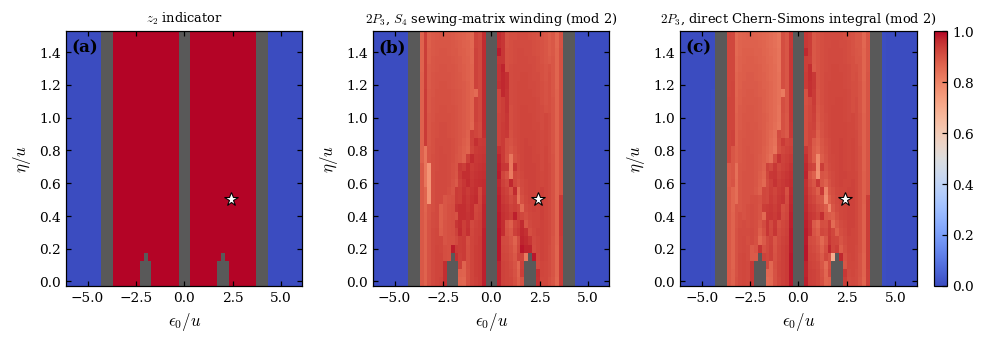

In [12]:
xs = np.linspace(-6, 6, 61)
ys = np.linspace(0.0, 1.5, 31)
maps = {}
for yname in ("m_z", "eta"):
    print(f"eps0 x {yname} map:")
    maps[yname] = S.p3_phase_map("eps0", xs, yname, ys, P)
    fig = S.plot_p3_map("eps0", xs, yname, ys, maps[yname], mark=(P["eps0"], P[yname]))
    S.save_figure(fig, f"figure/S4model_p3map_eps0_{yname}")
    for method, st in S.p3_map_report(maps[yname]).items():
        print(f"  {method:8s}: {st}")

**Result.** In the $\epsilon_0$–$\eta$ diagram all 1592 insulating points are resolved and both $2P_3$ evaluations agree
with $z_2$ on every one of them. In the $\epsilon_0$–$m_z$ diagram 1009 points are insulating, none has a nonzero plane Chern
number, there is **no mismatch**, and only a handful of cells (4 for the sewing-matrix winding, 7 for the direct integral)
remain unresolved: they all have $z_2=1$, bulk gaps below $0.16u$, and touch the $m_z\approx 2\eta$ boundary near
$\epsilon_0\approx\pm1.3$ where the X-line band inversion closes the gap; there even $n_k=64$ is not converged
(the folded value drifts from 1 towards $1/2$, never to 0). The direct Chern–Simons value and the $S_4$ sewing-matrix
winding track each other cell by cell, confirming $2P_3=W[B]\bmod 2$ independently of the indicator formula, and both
reproduce the $z_2$ map. (The two maps take about 20 minutes each on a laptop; lower the grid sizes to re-run quickly.)

## 9. The same maps with the constant-reference projector frame of Sec. 5

For comparison, the maps of Sec. 8 are recomputed with the frame $U_{\rm occ}=P_{\rm occ}R\,(R^\dagger P_{\rm occ}R)^{-1/2}$
(`projector_frames`, best of the five references in `REFS` at every parameter point), again with the same adaptive
$k$-grid and with the direct Chern–Simons integral evaluated in the same frame. The $z_2$ panel is identical to Sec. 8
(it only uses the $S_4$ eigenvalues). The additional panel shows the smallest eigenvalue of $R^\dagger P_{\rm occ}R$ over
the $k$-grid, i.e. how close the frame comes to being singular. Where this overlap drops to $10^{-3}$ or below the frame
is not smooth on any affordable grid and both $2P_3$ evaluations return values near $1/2$: not a wrong answer, but no answer.


eps0 x m_z map, constant-reference projector frame:
    eps0 = -6.00: 31 insulating points done, 7 s
    eps0 = -4.00: 208 insulating points done, 57 s
    eps0 = -2.00: 368 insulating points done, 272 s
    eps0 = +0.00: 502 insulating points done, 434 s
    eps0 = +2.00: 658 insulating points done, 669 s
    eps0 = +4.00: 798 insulating points done, 847 s
    eps0 = +6.00: 1009 insulating points done, 895 s
  winding : {'n_points': 1009, 'n_unresolved': 42, 'n_mismatch': 0, 'worst_resolved': 0.25303080767501496, 'n_nonzero_chern': 0, 'nk_used': {24: 718, 36: 86, 48: 205}}
  cs      : {'n_points': 1009, 'n_unresolved': 44, 'n_mismatch': 0, 'worst_resolved': 0.28631383102719987, 'n_nonzero_chern': 0, 'nk_used': {24: 718, 36: 86, 48: 205}}
  unresolved points: eps0 in [-2.0, -1.8, 1.8, 2.0], min overlap there <= 3.8e-03
eps0 x eta map, constant-reference projector frame:
    eps0 = -6.00: 31 insulating points done, 7 s
    eps0 = -4.00: 279 insulating points done, 63 s
    eps0 = -2.00:

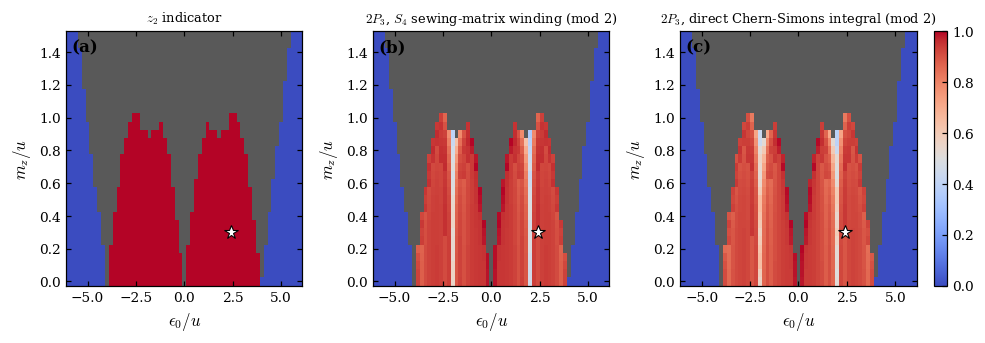

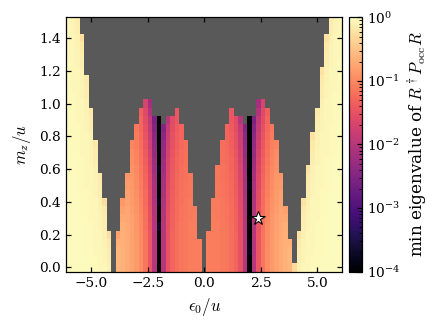

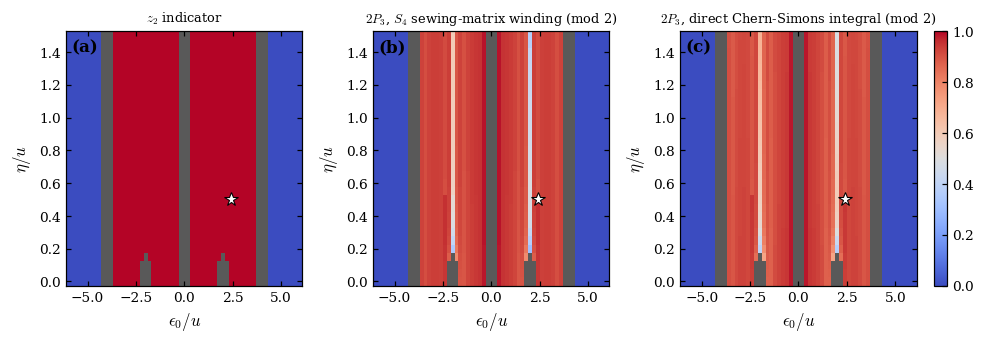

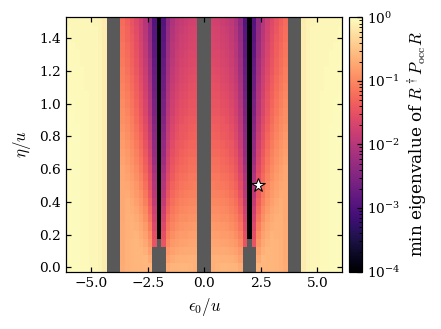

In [13]:
maps_proj = {}
for yname in ("m_z", "eta"):
    print(f"eps0 x {yname} map, constant-reference projector frame:")
    maps_proj[yname] = S.p3_phase_map_projector("eps0", xs, yname, ys, P, nks=(24, 36, 48))
    fig = S.plot_p3_map("eps0", xs, yname, ys, maps_proj[yname], mark=(P["eps0"], P[yname]))
    S.save_figure(fig, f"figure/S4model_p3map_projector_eps0_{yname}")
    fig = S.plot_overlap_map("eps0", xs, yname, ys, maps_proj[yname], mark=(P["eps0"], P[yname]))
    S.save_figure(fig, f"figure/S4model_overlap_projector_eps0_{yname}")
    for method, st in S.p3_map_report(maps_proj[yname]).items():
        print(f"  {method:8s}: {st}")
    r = maps_proj[yname]
    bad = ~r["gapless"] & r["chern_ok"] & (np.minimum(S.fold_mod2(r["winding"]), 1 - S.fold_mod2(r["winding"])) > 0.3)
    print(f"  unresolved points: eps0 in {sorted(set(np.round(xs[np.where(bad)[0]], 2)))}, "
          f"min overlap there <= {np.nanmax(r['min_overlap'][bad]) if bad.any() else float('nan'):.1e}")

**Result.** With the constant-reference frame the two methods still never *contradict* $z_2$ (no resolved mismatch),
but a whole family of insulating points is left unresolved: the lines $\epsilon_0=\pm2$ (42 of 1009 points in the $m_z$ map, including the neighbouring $\pm1.8$, and 54 of 1592 in the $\eta$ map), where the
overlap eigenvalue of the best available reference collapses to $\lesssim4	imes10^{-3}$ (down to $10^{-4}$), the frame changes by $O(1)$ between
neighbouring grid points even at $n_k=48$, and the folded $2P_3$ sits at $\approx0.5$. These are the parameters of the band inversion on the $X$–$R$ line: at $\epsilon_0=2$ ($-2$) the occupied
space at $R$ ($X$) is exactly the $A$ orbital, so the $B$-orbital reference has zero overlap there, and none of the other
references in the set does better anywhere on these lines. Away from these lines the projector frame gives
the same numbers as the smooth frame of Sec. 8 (e.g. $0.936$ vs $0.925$ at $n_k=24$), which is why it was adequate at the
reference point. The comparison makes the point of Sec. 8 concrete: the sewing-matrix winding is only defined in a globally
smooth gauge, and the constant-reference construction does not provide one for every parameter, whereas the parallel-transport
frame does.

## Summary

| check | result |
|---|---|
| magnetic point group | exactly $\bar4$ |
| bulk gap | $\approx1.44$ |
| $S_4$ data | $e^{\pm i\pi/4}$ at $Z$, $e^{\pm i3\pi/4}$ at $\Gamma,M,A$ |
| indicators / Chern | $(0,0,1)$, all plane Chern numbers 0 |
| $2P_3$ | $\to1$ ($0.95,0.97,0.99$ for $n_k=32,48,64$) |
| occupied-band nodes | 4 symmetry-enforced Weyl points (chirality $\pm1$), harmless for $2P_3$ |
| $2P_3$ vs $z_2$ over the phase diagrams | agree on every resolved insulating point; direct Chern–Simons integral agrees with the $S_4$ sewing-matrix winding |
| constant-reference projector frame on the maps | agrees where its overlap is finite; unresolved (no answer) on the lines $\epsilon_0=\pm2$ where the overlap vanishes |
